<a href="https://colab.research.google.com/github/Ali-Hamza-developer/pytorch/blob/main/07_training_pipeline_nn_module_with_dataloader.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Breast Cancer Classification — `nn.Module` + `Dataset` & `DataLoader`

**Ali Hamza**
🔗 [LinkedIn](https://www.linkedin.com/in/alihamzastudent/)

---

This is the breast cancer training pipeline again — but this time with one upgrade added on top of the `nn.Module` version: **mini-batch training** using `Dataset` and `DataLoader`, instead of feeding the entire 455-row training set to the model in one shot.

| | `05_training_pipeline_using_nn_module` | This notebook |
|---|---|---|
| Model | `nn.Linear` + `nn.Sigmoid` | same |
| Loss | `nn.BCELoss()` | same |
| Optimizer | `torch.optim.SGD` | same |
| Data fed to model | entire training set at once (full-batch) | small batches via `DataLoader` (mini-batch) |
| Training loop | single loop over epochs | **nested** loop: epochs → batches |

Everything else — loading, cleaning, splitting, scaling, encoding — is unchanged.

### 🔄 Full pipeline overview

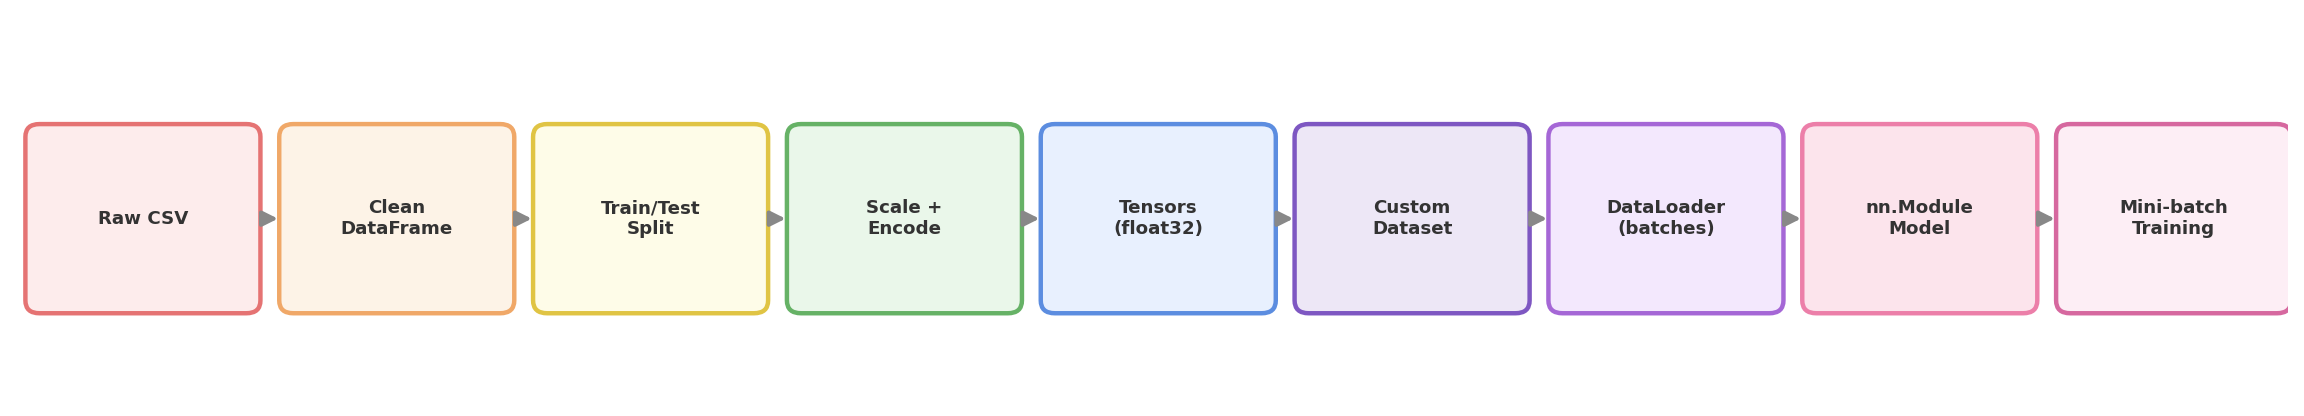

## Step 1 — Import Libraries

In [1]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder

## Step 2 — Load the Dataset

In [2]:
# load dataset directly from a CSV hosted on GitHub
df = pd.read_csv('https://raw.githubusercontent.com/gscdit/Breast-Cancer-Detection/refs/heads/master/data.csv')

# quick look at the first few rows
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [3]:
# check dataset size: (rows, columns)
df.shape

(569, 33)

### Cleaning the data

- `id` → just a row identifier, no predictive value
- `Unnamed: 32` → empty leftover column from the CSV export

> ⚠️ **Common mistake:** forgetting to drop `id` lets the model "cheat" by memorizing ID numbers instead of learning real patterns.

In [4]:
# remove unnecessary columns permanently (inplace=True)
df.drop(columns=['id', 'Unnamed: 32'], inplace=True)

# confirm the columns are gone
df.head()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


## Step 3 — Train / Test Split

`test_size=0.2` → 80% train, 20% test, so the model is evaluated on data it never trained on.

In [5]:
X_train, X_test, y_train, y_test = train_test_split(df.iloc[:, 1:], df.iloc[:, 0], test_size=0.2)

## Step 4 — Feature Scaling

`StandardScaler` rescales every feature to **mean = 0, std = 1**.

> ⚠️ **Important rule:** fit the scaler only on `X_train`, then just `transform` `X_test` — never re-fit on test data.

In [6]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## Step 5 — Label Encoding

`M` → `1` (Malignant), `B` → `0` (Benign).

In [7]:
encoder = LabelEncoder()
y_train = encoder.fit_transform(y_train)
y_test = encoder.transform(y_test)

## Step 6 — Convert NumPy Arrays to PyTorch Tensors

`.astype(np.float32)` avoids the `float64` vs `float32` dtype mismatch that `nn.Linear` and `nn.BCELoss` would otherwise throw.

In [8]:
X_train_tensor = torch.from_numpy(X_train.astype(np.float32))
X_test_tensor = torch.from_numpy(X_test.astype(np.float32))
y_train_tensor = torch.from_numpy(y_train.astype(np.float32))
y_test_tensor = torch.from_numpy(y_test.astype(np.float32))

In [9]:
X_train_tensor.shape

torch.Size([455, 30])

## Step 7 — Wrap the Training Data in a Custom `Dataset`

Same two required methods as before — `__len__` and `__getitem__` — this time wrapping the real, scaled breast cancer tensors instead of synthetic data.

In [10]:
class BreastCancerDataset(Dataset):

  def __init__(self, features, labels):

    self.features = features
    self.labels = labels

  def __len__(self):

    return self.features.shape[0]

  def __getitem__(self, index):

    return self.features[index], self.labels[index]

In [11]:
train_dataset = BreastCancerDataset(X_train_tensor, y_train_tensor)

len(train_dataset)

455

## Step 8 — Wrap it in a `DataLoader`

`batch_size=32` — a common default; with 455 training samples that's about 15 batches per epoch, instead of 1 giant full-batch pass. `shuffle=True` — reshuffles the sample order every epoch, so the model doesn't learn anything from the row order in the CSV.

In [12]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

## Step 9 — Defining the Model with `nn.Module`

Unchanged from the previous notebook — 30 inputs, one output neuron, sigmoid activation.

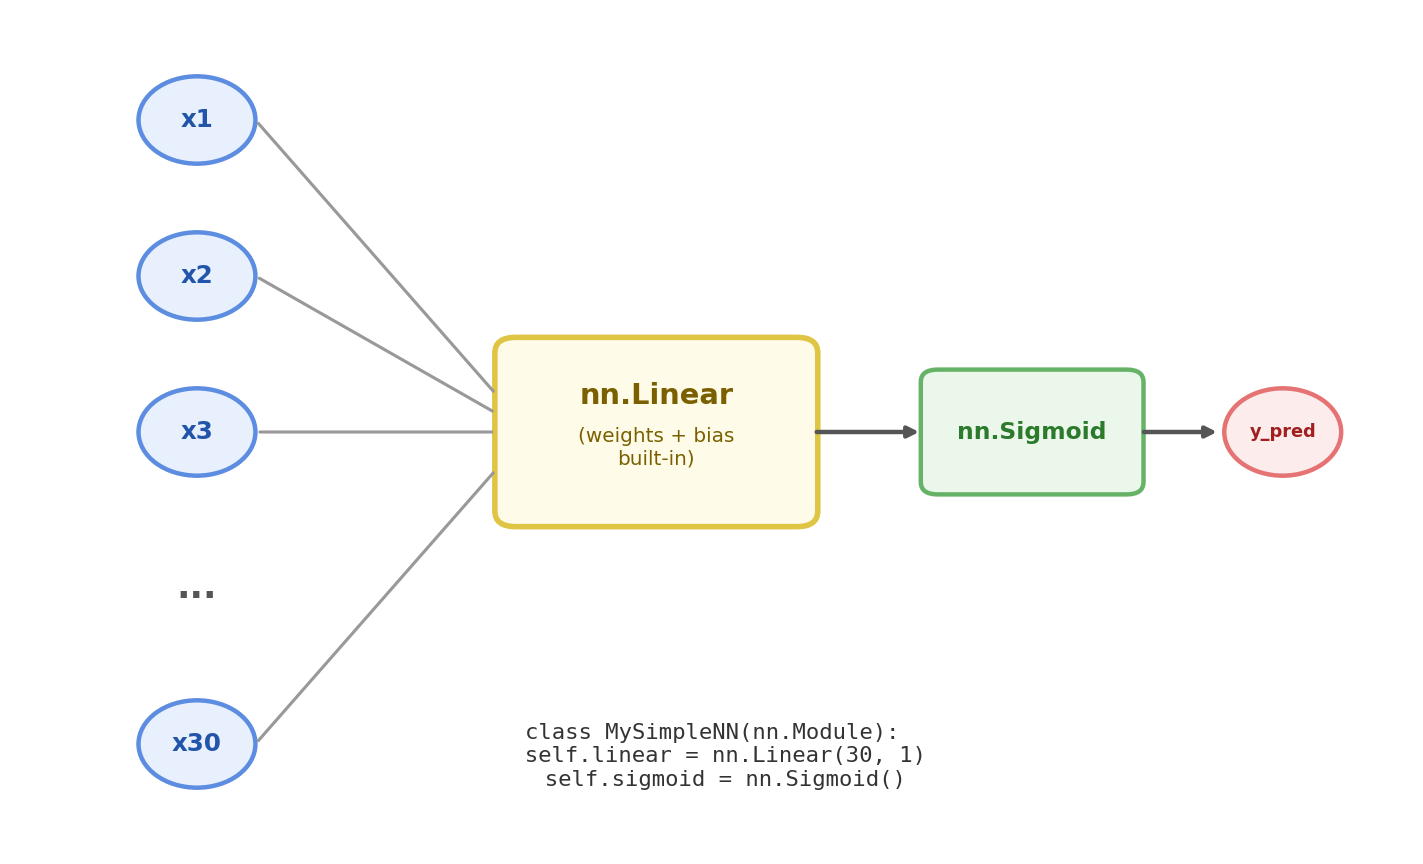

In [13]:
class MySimpleNN(nn.Module):

  def __init__(self, num_features):

    super().__init__()
    self.linear = nn.Linear(num_features, 1)
    self.sigmoid = nn.Sigmoid()

  def forward(self, features):

    out = self.linear(features)
    out = self.sigmoid(out)

    return out

## Step 10 — Important Parameters

In [14]:
learning_rate = 0.1
epochs = 100

## Step 11 — Loss Function

In [15]:
loss_function = nn.BCELoss()

## Step 12 — Mini-Batch Training Pipeline

This is the one real change from the previous notebook: the training loop now has **two levels**. The outer loop still runs once per epoch — but instead of calling the model on the whole training set, it now loops over `train_loader`, running the same 5-step cycle (forward → loss → zero grad → backward → step) **once per batch**.

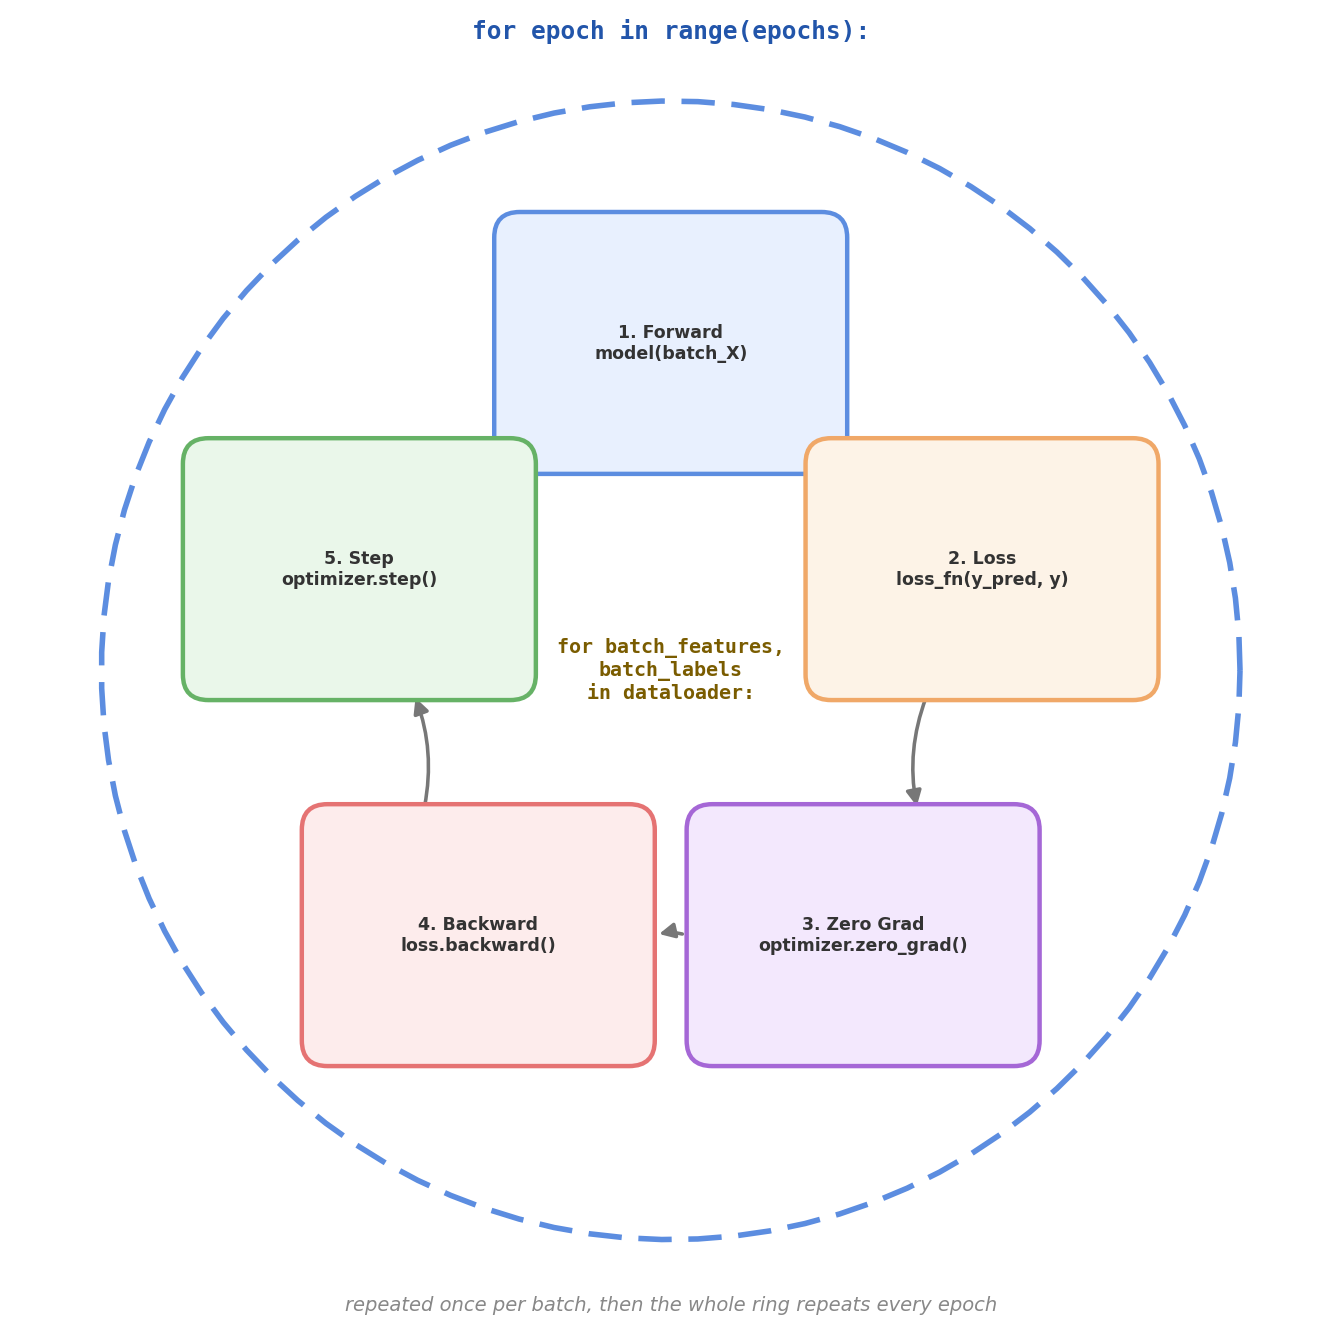

- **Outer loop (`for epoch in range(epochs)`)** — one full pass over the entire dataset
- **Inner loop (`for batch_features, batch_labels in train_loader`)** — one pass per *batch*; the model's weights get updated after every batch, not just once per epoch

Because loss is now computed per-batch rather than once for the whole dataset, it's tracked and averaged across batches to get one meaningful loss value per epoch to print.

> ⚠️ **Shape note (same as before):** `batch_labels` comes out of the `DataLoader` as shape `[batch_size]` (1D), but the model's output is `[batch_size, 1]` (2D) — `batch_labels.view(-1, 1)` fixes the mismatch before computing loss.

In [16]:
# create model
model = MySimpleNN(X_train_tensor.shape[1])

# define optimizer
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)

# define loop
for epoch in range(epochs):

  total_loss = 0.0

  # inner loop - one iteration per batch
  for batch_features, batch_labels in train_loader:

    # forward pass
    y_pred = model(batch_features)

    # loss calculate
    loss = loss_function(y_pred, batch_labels.view(-1, 1))

    # clear gradients
    optimizer.zero_grad()

    # backward pass
    loss.backward()

    # parameters update
    optimizer.step()

    total_loss += loss.item()

  # average loss across all batches this epoch
  avg_loss = total_loss / len(train_loader)
  print(f'Epoch: {epoch + 1}, Loss: {avg_loss:.4f}')

Epoch: 1, Loss: 0.3179
Epoch: 2, Loss: 0.1727
Epoch: 3, Loss: 0.1353
Epoch: 4, Loss: 0.1154
Epoch: 5, Loss: 0.0989
Epoch: 6, Loss: 0.0914
Epoch: 7, Loss: 0.0882
Epoch: 8, Loss: 0.0808
Epoch: 9, Loss: 0.0767
Epoch: 10, Loss: 0.0760
Epoch: 11, Loss: 0.0725
Epoch: 12, Loss: 0.0701
Epoch: 13, Loss: 0.0867
Epoch: 14, Loss: 0.0705
Epoch: 15, Loss: 0.0641
Epoch: 16, Loss: 0.0631
Epoch: 17, Loss: 0.0625
Epoch: 18, Loss: 0.0604
Epoch: 19, Loss: 0.0610
Epoch: 20, Loss: 0.0588
Epoch: 21, Loss: 0.0570
Epoch: 22, Loss: 0.0563
Epoch: 23, Loss: 0.0735
Epoch: 24, Loss: 0.0550
Epoch: 25, Loss: 0.0531
Epoch: 26, Loss: 0.0528
Epoch: 27, Loss: 0.0542
Epoch: 28, Loss: 0.0709
Epoch: 29, Loss: 0.0513
Epoch: 30, Loss: 0.0499
Epoch: 31, Loss: 0.0498
Epoch: 32, Loss: 0.0518
Epoch: 33, Loss: 0.0496
Epoch: 34, Loss: 0.0512
Epoch: 35, Loss: 0.0489
Epoch: 36, Loss: 0.0474
Epoch: 37, Loss: 0.0629
Epoch: 38, Loss: 0.0467
Epoch: 39, Loss: 0.0495
Epoch: 40, Loss: 0.0461
Epoch: 41, Loss: 0.0475
Epoch: 42, Loss: 0.0490
E

> 📉 **What to look for:** the average loss should trend downward, same as the full-batch version — but expect it to look a little noisier epoch to epoch, since each batch nudges the weights based on only part of the data rather than all of it at once.

## Step 13 — Model Evaluation

Evaluation still runs on the full test set in one shot — batching matters for *training* efficiency, but for a one-time evaluation pass there's no need to split it up.

In [17]:
# model evaluation
with torch.no_grad():
  y_pred = model.forward(X_test_tensor)
  y_pred = (y_pred > 0.5).float()
  accuracy = (y_pred == y_test_tensor).float().mean()
  print(f'Accuracy: {accuracy.item()}')

Accuracy: 0.5147737860679626


---

## ✅ Summary

- Same data pipeline, same `nn.Module` model, same `nn.BCELoss` + `torch.optim.SGD` as the previous notebook
- **What's new:** training data now flows through a `BreastCancerDataset` + `DataLoader(batch_size=32, shuffle=True)` instead of being passed to the model all at once
- The training loop gained an inner loop over batches — weights update once per **batch**, not once per **epoch** — and loss is now averaged across batches per epoch for a fair comparison
- Everything about the model itself (`MySimpleNN`) is untouched — swapping in mini-batch training only required changing how data is *fed in*, not how the model is defined

**Where to go from here:** try different `batch_size` values (8, 16, 64) and compare how the loss curve and final accuracy change — smaller batches mean noisier but more frequent updates, larger batches mean smoother but fewer updates per epoch.

---
**Ali Hamza** · [LinkedIn](https://www.linkedin.com/in/alihamzastudent/)